# Thai Character Dataset: Basic Exploration

This notebook inspects the `round2` Thai character image dataset. Each class folder is named with the decimal value of a TIS-620 encoded Thai character.

In [ ]:
from pathlib import Path
import math
import random

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

DATASET_DIR = (Path.cwd() / '..' / '..' / 'ThaiCharacter Dataset' / 'round2').resolve()
if not DATASET_DIR.exists():
    raise FileNotFoundError(f'Dataset directory not found: {DATASET_DIR}')

IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
print(f'Dataset directory: {DATASET_DIR}')

Dataset directory: D:\vscode\kmitl\3-1\dlmed\ThaiCharacter Dataset\round2


## Decode TIS-620 class labels

The folder names are decimal byte values. The helper below converts each value to its Thai character.

In [2]:
def tis620_number_to_character(number):
    """Convert a decimal TIS-620 byte value to its Thai character."""
    value = int(number)
    if not 0 <= value <= 255:
        raise ValueError('A TIS-620 byte value must be between 0 and 255.')
    return bytes([value]).decode('tis-620')

for value in [161, 162, 184, 185]:
    print(f'{value} -> {tis620_number_to_character(value)}')

161 -> ก
162 -> ข
184 -> ธ
185 -> น


In [3]:
class_dirs = sorted(
    (path for path in DATASET_DIR.iterdir() if path.is_dir() and path.name.isdigit()),
    key=lambda path: int(path.name),
)

records = []
for class_dir in class_dirs:
    image_paths = sorted(
        path for path in class_dir.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )
    class_number = int(class_dir.name)
    records.append({
        'class_number': class_number,
        'character': tis620_number_to_character(class_number),
        'image_count': len(image_paths),
        'folder': class_dir.name,
        'image_paths': image_paths,
    })

class_table = pd.DataFrame(records)
print(f'Number of classes: {len(class_table)}')
print(f'Total images: {class_table["image_count"].sum():,}')
class_table[['class_number', 'character', 'image_count']]

Number of classes: 72
Total images: 62,707


,class_number,character,image_count
0,161,ก,1951
1,162,ข,1355
2,163,ฃ,1
3,164,ค,1448
4,167,ง,1078
...,...,...,...
67,245,๕,17
68,246,๖,12
69,247,๗,4
70,248,๘,27


## One random image from every class

The complete class set is shown simultaneously. The fixed seed makes the selected image reproducible.

C:\Users\poka\AppData\Local\Temp\ipykernel_23312\2171168914.py:25: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  figure.tight_layout()
C:\Users\poka\AppData\Local\Temp\ipykernel_23312\2171168914.py:25: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) DejaVu Sans.
  figure.tight_layout()
C:\Users\poka\AppData\Local\Temp\ipykernel_23312\2171168914.py:25: UserWarning: Glyph 3587 (\N{THAI CHARACTER KHO KHUAT}) missing from font(s) DejaVu Sans.
  figure.tight_layout()
C:\Users\poka\AppData\Local\Temp\ipykernel_23312\2171168914.py:25: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  figure.tight_layout()
C:\Users\poka\AppData\Local\Temp\ipykernel_23312\2171168914.py:25: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  figure.tight_layout()
C:\Users\poka\AppData\Local\Temp\ipykernel_23312\2171168914.py:25: UserWarning: Glyph 3592 (\N{THAI CHARAC

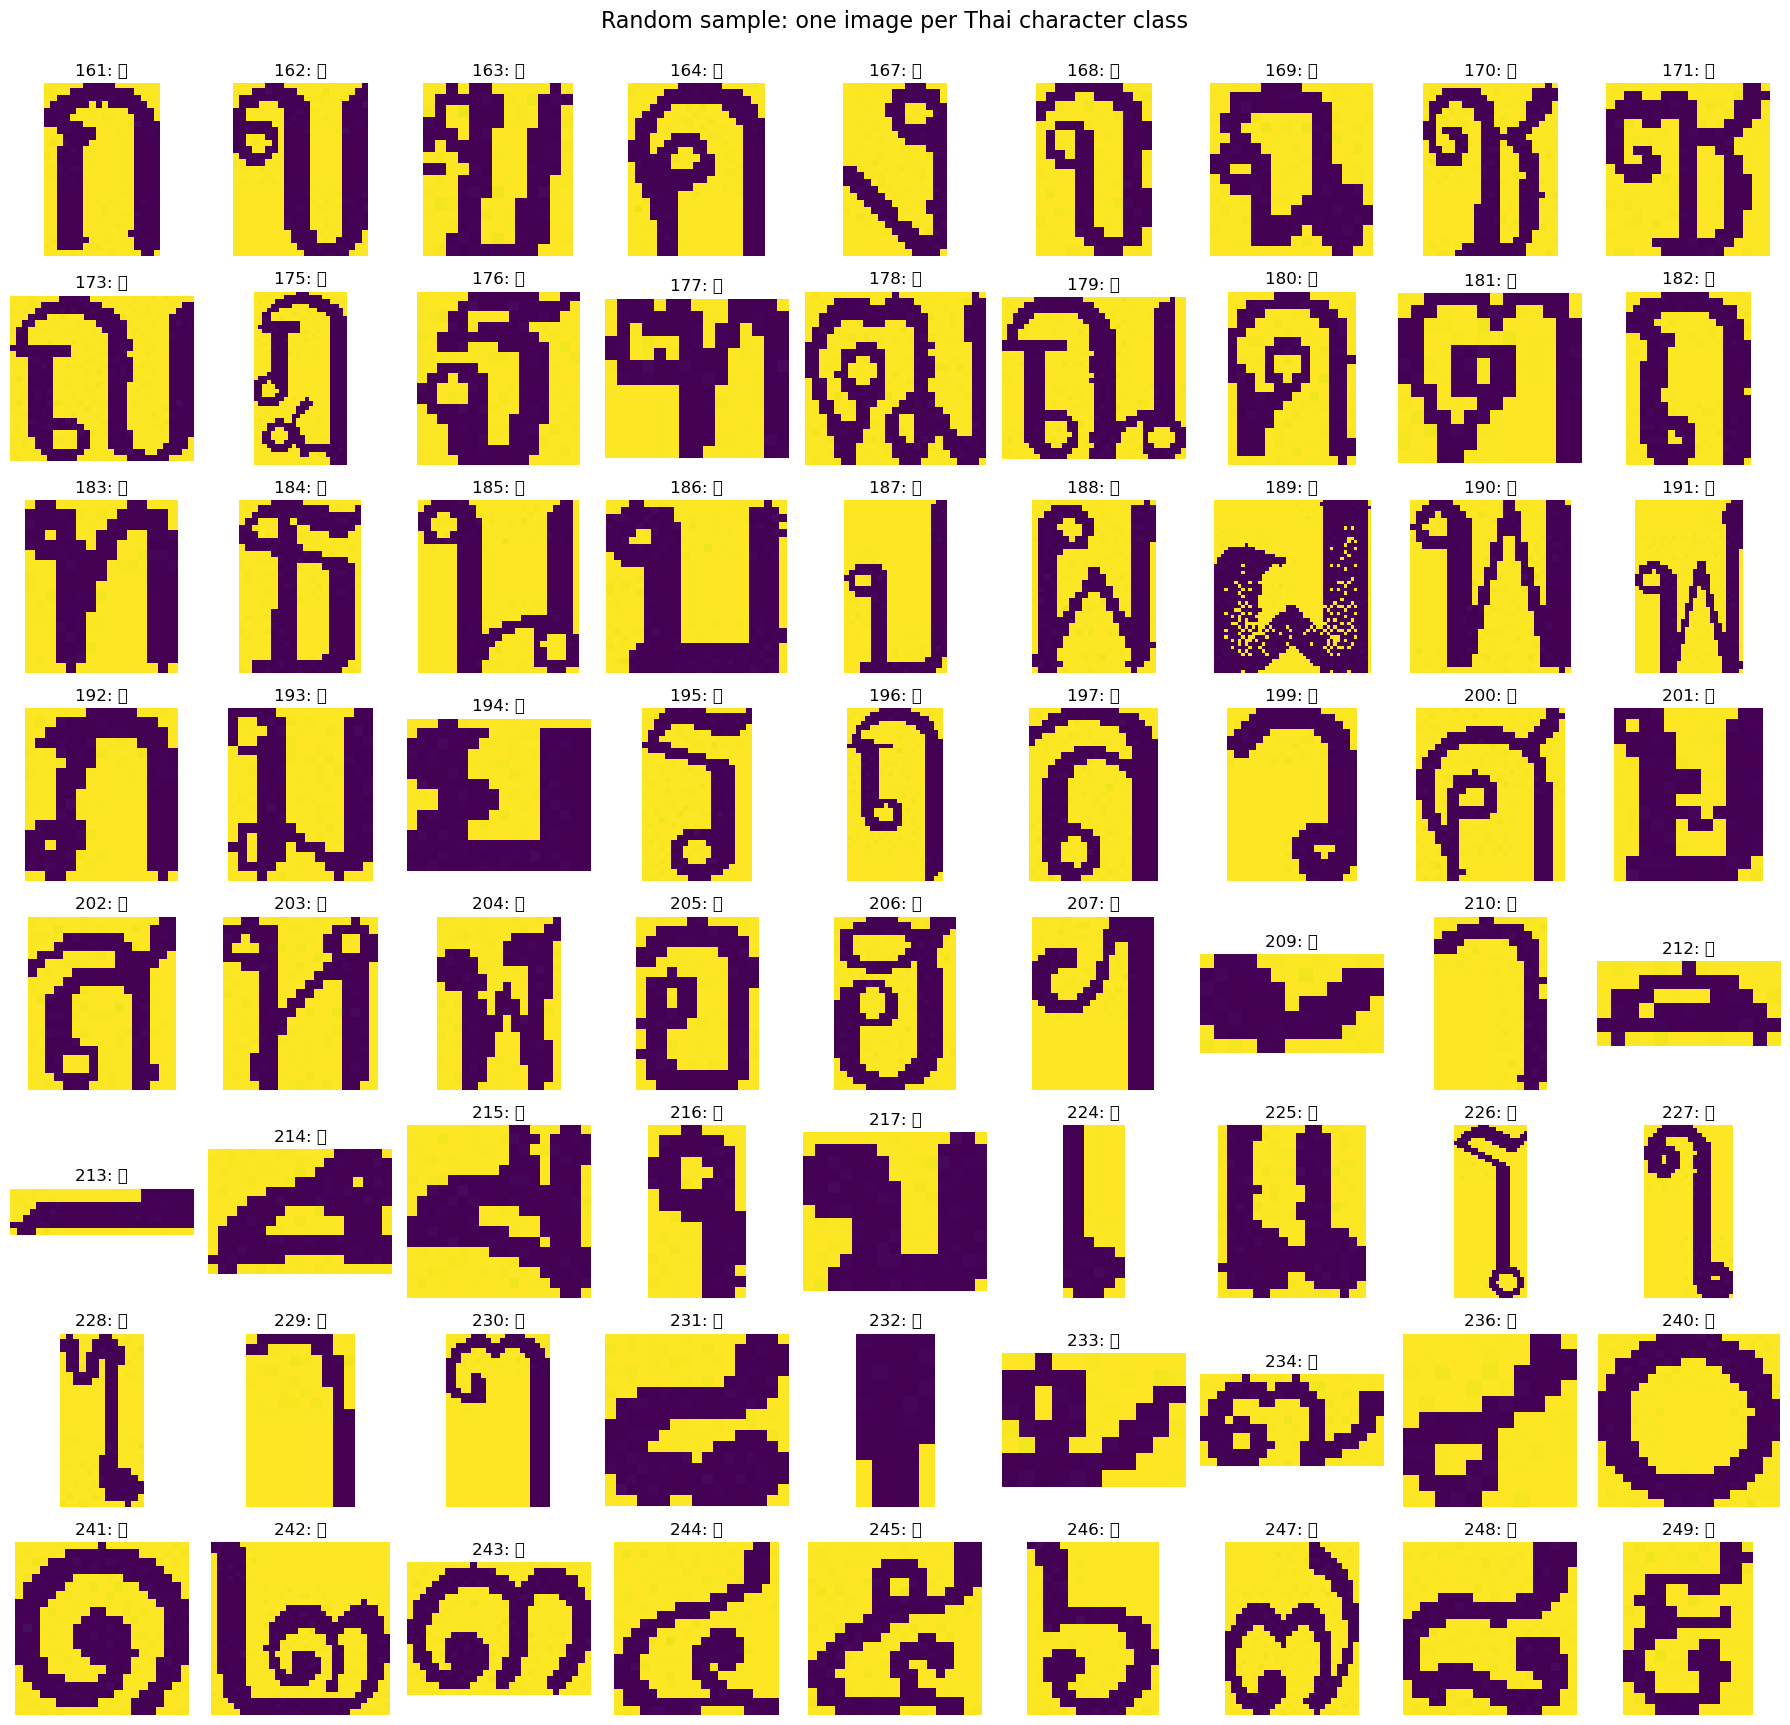

In [7]:
RANDOM_SEED = 420

random_generator = random.Random()
samples = [
    (row.class_number, row.character, random_generator.choice(row.image_paths))
    for row in class_table.itertuples()
    if row.image_paths
]

columns = 9
rows = math.ceil(len(samples) / columns)
figure, axes = plt.subplots(rows, columns, figsize=(18, rows * 2.15))
axes = axes.ravel()

for axis, (class_number, character, image_path) in zip(axes, samples):
    with Image.open(image_path) as image:
        axis.imshow(image)
    axis.set_title(f'{class_number}: {character}', fontsize=12)
    axis.axis('off')

for axis in axes[len(samples):]:
    axis.axis('off')

figure.suptitle('Random sample: one image per Thai character class', fontsize=16, y=1.0)
figure.tight_layout()
plt.show()